In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, confusion_matrix

import numpy as np
import matplotlib.pyplot as plt

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [7]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:11<00:00, 14.7MB/s] 
/home/alexa/miniconda3/envs/labs-2025/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [9]:
classes = train_dataset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [10]:
class SimpleCNN(nn.Module):
    
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*8*8,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self,x):

        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)

        return x

In [11]:
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
epochs = 10

for epoch in range(epochs):

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:", running_loss/len(train_loader))

Epoch 1 Loss: 1.278267358117701
Epoch 2 Loss: 0.9076689379599393
Epoch 3 Loss: 0.738345889674733
Epoch 4 Loss: 0.5962070625303956
Epoch 5 Loss: 0.46614688086082867
Epoch 6 Loss: 0.3454548867652788
Epoch 7 Loss: 0.2432203927479894
Epoch 8 Loss: 0.16307789500316847
Epoch 9 Loss: 0.12008058818538322
Epoch 10 Loss: 0.0831928940104616


In [13]:
model.eval()

correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted.cpu() == labels).sum().item()

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = correct/total

print("Accuracy:", accuracy)

Accuracy: 0.7191


In [14]:
f1 = f1_score(y_true, y_pred, average="macro")

print("Macro F1 Score:", f1)

Macro F1 Score: 0.7193898262390465


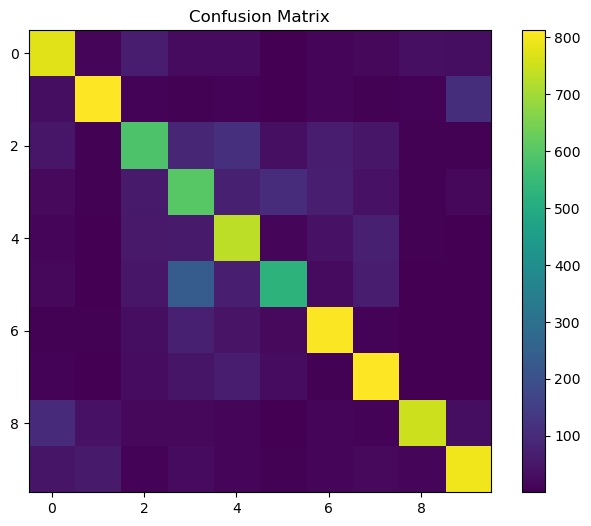

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()